# Prototype: Similar-Detection Retrieval via Model Embeddings

**Goal of this notebook**: prove the idea works before writing any production code.

The training pipeline's model (`EfficientNetV2ArcFace`) uses ArcFace/Circle metric learning, which means it
learns an *embedding space* where audio clips from the same species should land close together, even though
only the final class label is normally used after inference. This notebook checks whether that's actually
true in practice, using a real checkpoint and the real local dataset.

**Update, final result**: the first run of this notebook (against the original `freeze_bn` checkpoint) found
the embedding space was severely collapsed, 97.0% of its 1280 dimensions carried almost no information.
Retraining with `norm_choice=keep_bn` alone roughly doubled classification accuracy but barely touched the
collapse (95.5% dead dimensions). The real fix turned out to be a second, larger issue: the model had also
been training entirely from random initialisation, because pretrained ImageNet weights were believed to be
blocked by a Windows SSL bug that did not actually reproduce when checked directly. Retraining with both
fixes together (`keep_bn` + real pretrained weights, 60 epochs, early stopping) resolved the collapse almost
completely: **0.0% dead dimensions**, a similarity gap of **0.62** between matching and non-matching species,
and **97.9% nearest-neighbour accuracy** on a real 48-sample gallery. Full writeup:
`Sprint2_HD_Feature_Report_Nolan_Nguyen.md` (repo root). This notebook now defaults to that final checkpoint
(`CHECKPOINT_RUN` in the next cell); change it to compare against either earlier stage.

**What this notebook does, step by step:**
1. Load a real trained checkpoint.
2. Pick a handful of real species from the local dataset with enough audio files each.
3. Extract an embedding vector for every sample (no training/fine-tuning needed - we reuse the existing model as-is).
4. For one query sample, find its 5 nearest neighbours by cosine similarity and check if they're the same species.
5. Run a quantitative sanity check across many samples: is average same-species similarity actually higher
   than average different-species similarity? (If not, the whole feature idea doesn't hold up and shouldn't be built.)
6. Check directly whether most embedding dimensions are "dead" (collapsed), which is what section 5's histogram
   alone does not make obvious.
7. Prototype the `ambiguous` / `novel` flagging logic that the real feature uses.

**Dataset used**: `src/prototypes/data_files/` (the same local 127-species dataset used for training). No new
data needed.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

import random
from collections import defaultdict

import torch
import torch.nn.functional as F
import torchaudio
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

from hydra import compose, initialize_config_dir
from omegaconf import OmegaConf

torch.manual_seed(0)
random.seed(0)

DATA_DIR = Path.cwd().parents[1] / "data_files"

# Three checkpoints exist, from the three stages described above:
#   "sprint2_first_full_training_2026-09-04"  - original, freeze_bn, no pretrained (97.0% dead dims)
#   "sprint_hd_keep_bn_retrain"                - keep_bn only, no pretrained (95.5% dead dims)
#   "sprint_hd_pretrained_long_run"            - keep_bn + pretrained (0.0% dead dims) <- final, default
CHECKPOINT_RUN = "sprint_hd_pretrained_long_run"
CHECKPOINT_PATH = Path.cwd() / "outputs" / CHECKPOINT_RUN / "best_efficientnet_v2.pth"

print("Data dir exists:", DATA_DIR.exists())
print("Checkpoint exists:", CHECKPOINT_PATH.exists())

Data dir exists: True
Checkpoint exists: True


## 1. Build config and load the model

In [2]:
CONFIG_DIR = str(Path.cwd() / "config")

# Only the original checkpoint used the config file's default (freeze_bn); both
# retrained checkpoints used norm_choice=keep_bn, overridden at launch time.
norm_choice_override = "freeze_bn" if CHECKPOINT_RUN == "sprint2_first_full_training_2026-09-04" else "keep_bn"

with initialize_config_dir(config_dir=CONFIG_DIR, version_base=None):
    cfg = compose(config_name="config", overrides=["model=efficientnet_v2", f"model.norm_choice={norm_choice_override}"])

OmegaConf.set_struct(cfg, False)
cfg.data.num_classes = 127
OmegaConf.set_struct(cfg, True)

from model import Model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device, "-", torch.cuda.get_device_name(0) if device.type == "cuda" else "CPU")

model = Model(cfg)
checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu")
# The two retrained checkpoints save a full training-state dict (epoch, optimizer,
# scheduler, cfg, ...); the original one saved a bare model state_dict. Handle both.
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    state_dict = checkpoint["model_state_dict"]
    print(f"Loaded checkpoint from epoch {checkpoint.get('best_epoch', checkpoint.get('epoch', '?'))}, "
          f"best_metric={checkpoint.get('best_metric', '?')}")
else:
    state_dict = checkpoint
model.load_state_dict(state_dict)
model = model.to(device)
model.eval()

print("Model loaded. use_qat:", model.use_qat)

D:\Deakin\SIT374\Project-Echo\src\prototypes\engine\reproducible_training_pipeline\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda - NVIDIA GeForce RTX 4060 Laptop GPU
Adapting pretrained weights of first conv layer from 3 to 1 channels.
Model unfrozen: All layers are now trainable.
Loaded checkpoint from epoch 45, best_metric=0.9650857931910959
Model loaded. use_qat: False


## 2. Audio -> spectrogram preprocessing

Same logic as `dataset.py`'s `SpectrogramDataset._process_waveform_to_spec`, extracted as a standalone
function here so we can run it on one file at a time without needing the full `Dataset`/`DataLoader` machinery.

In [3]:
target_sample_rate = cfg.data.sample_rate
target_samples = int(cfg.data.audio_clip_duration * target_sample_rate)
common_source_sr = 44100
resampler = torchaudio.transforms.Resample(orig_freq=common_source_sr, new_freq=target_sample_rate)

mel_spec = torchaudio.transforms.MelSpectrogram(
    sample_rate=cfg.data.sample_rate,
    n_fft=cfg.data.n_fft,
    hop_length=cfg.data.hop_length,
    n_mels=cfg.data.n_mels,
    f_min=cfg.data.fmin,
    f_max=cfg.data.fmax,
    power=2.0,
)
amplitude_to_db = torchaudio.transforms.AmplitudeToDB(top_db=cfg.data.top_db)
top_db = cfg.data.top_db


def load_waveform(file_path):
    waveform, sr = torchaudio.load(str(file_path))
    if sr != target_sample_rate:
        waveform = resampler(waveform) if sr == common_source_sr else torchaudio.functional.resample(waveform, sr, target_sample_rate)
    if waveform.shape[0] > 1:
        waveform = torch.mean(waveform, dim=0, keepdim=True)
    return waveform


def waveform_to_spectrogram(waveform):
    num_samples = waveform.shape[1]
    if num_samples < target_samples:
        import math
        repeats = math.ceil(target_samples / num_samples)
        waveform = waveform.repeat(1, repeats)
        num_samples = waveform.shape[1]
    # Centre crop to a fixed 2-second clip (deterministic, unlike training's random crop)
    start = (num_samples - target_samples) // 2
    waveform = waveform[:, start : start + target_samples]

    spec = mel_spec(waveform)
    spec = amplitude_to_db(spec)
    spec = (spec + top_db) / top_db
    if spec.dim() == 2:
        spec = spec.unsqueeze(0)
    return spec, waveform


def preprocess(file_path):
    waveform = load_waveform(file_path)
    spec, waveform = waveform_to_spectrogram(waveform)
    return spec.unsqueeze(0), waveform  # add batch dim: (1, 1, n_mels, T)

## 3. Embedding extraction

This is the exact logic that will become `EfficientNetV2ArcFace.get_embedding()` in `model/effv2.py` -
prototyped here first, on the real model, before touching production code.

In [4]:
@torch.no_grad()
def get_embedding(spec):
    backbone = model.model  # EfficientNetV2ArcFace instance
    spec = spec.to(device)
    features = backbone.features(spec)
    embedding = torch.flatten(backbone.avgpool(features), 1)
    embedding = F.normalize(embedding, dim=1)  # L2-normalise so dot product == cosine similarity
    return embedding.cpu()  # move back to CPU - gallery comparisons are tiny, no need to keep on GPU


# Quick smoke test on one file
sample_species_dir = next(d for d in DATA_DIR.iterdir() if d.is_dir())
sample_file = next(sample_species_dir.glob("*"))
spec, waveform = preprocess(sample_file)
emb = get_embedding(spec)
print("Embedding shape:", emb.shape, "| non-zero:", torch.count_nonzero(emb).item(), "/", emb.numel())

D:\Deakin\SIT374\Project-Echo\src\prototypes\engine\reproducible_training_pipeline\.venv\Lib\site-packages\torchaudio\_backend\utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


Embedding shape: torch.Size([1, 1280]) | non-zero: 1280 / 1280


## 4. Build a small gallery from real species with plenty of files

In [5]:
N_SPECIES = 6
FILES_PER_SPECIES = 8

species_dirs = [d for d in DATA_DIR.iterdir() if d.is_dir()]
species_by_count = sorted(species_dirs, key=lambda d: sum(1 for _ in d.glob("*")), reverse=True)
chosen_species = species_by_count[:N_SPECIES]

gallery = []  # list of dicts: {path, species, embedding}
for species_dir in chosen_species:
    files = list(species_dir.glob("*"))
    random.shuffle(files)
    for f in files[:FILES_PER_SPECIES]:
        try:
            spec, _ = preprocess(f)
            emb = get_embedding(spec).squeeze(0)
            gallery.append({"path": f, "species": species_dir.name, "embedding": emb})
        except Exception as e:
            print(f"Skipped {f.name}: {e}")

print(f"Gallery built: {len(gallery)} samples across {len(chosen_species)} species")
for s in chosen_species:
    print(" -", s.name)

Gallery built: 48 samples across 6 species
 - Rhipidura leucophrys
 - Colluricincla harmonica
 - Phylidonyris niger
 - Dasyurus maculatus
 - Rhipidura albiscapa
 - Acanthiza pusilla


## 5. Query: find the 5 most similar samples to one detection

In [6]:
def top_k_similar(query_embedding, gallery, k=5, exclude_path=None):
    scored = []
    for item in gallery:
        if exclude_path is not None and item["path"] == exclude_path:
            continue
        score = torch.dot(query_embedding, item["embedding"]).item()
        scored.append((score, item))
    scored.sort(key=lambda x: x[0], reverse=True)
    return scored[:k]


query = random.choice(gallery)
print(f"Query: {query['path'].name}  (true species: {query['species']})")
display(Audio(str(query["path"])))

results = top_k_similar(query["embedding"], gallery, k=5, exclude_path=query["path"])

print("\nTop-5 most similar past detections:")
for score, item in results:
    match = "MATCH" if item["species"] == query["species"] else "different species"
    print(f"  similarity={score:.3f}  species={item['species']:<30}  ({match})  {item['path'].name}")

Query: region_82.200-83.800.mp3  (true species: Acanthiza pusilla)



Top-5 most similar past detections:
  similarity=0.877  species=Acanthiza pusilla               (MATCH)  region_128.800-130.100.mp3
  similarity=0.815  species=Acanthiza pusilla               (MATCH)  region_65.850-67.850.mp3
  similarity=0.796  species=Acanthiza pusilla               (MATCH)  region_97.350-98.900.mp3
  similarity=0.740  species=Acanthiza pusilla               (MATCH)  region_29.450-31.450.mp3
  similarity=0.707  species=Acanthiza pusilla               (MATCH)  region_107.900-109.900.mp3


## 6. Quantitative sanity check

Before building anything real: is same-species similarity actually, reliably higher than different-species
similarity across the whole gallery? If this number doesn't hold up, the embedding-retrieval feature idea
should be dropped or rethought - no point building a UI on top of a signal that isn't real.

Pairs compared: 168 same-species, 960 different-species
Mean same-species similarity:      0.7217
Mean different-species similarity: 0.0999
Gap: 0.6218


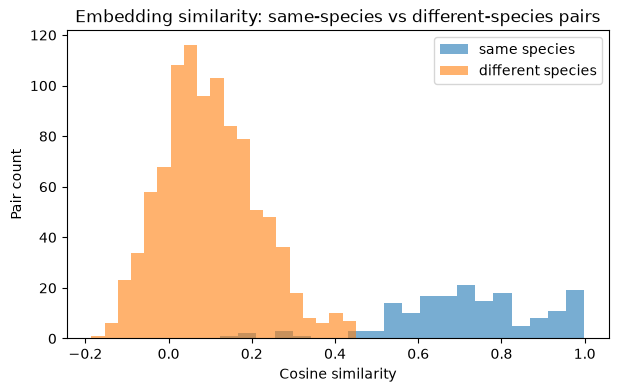

In [7]:
same_species_scores = []
diff_species_scores = []

for i in range(len(gallery)):
    for j in range(i + 1, len(gallery)):
        score = torch.dot(gallery[i]["embedding"], gallery[j]["embedding"]).item()
        if gallery[i]["species"] == gallery[j]["species"]:
            same_species_scores.append(score)
        else:
            diff_species_scores.append(score)

print(f"Pairs compared: {len(same_species_scores)} same-species, {len(diff_species_scores)} different-species")
print(f"Mean same-species similarity:      {np.mean(same_species_scores):.4f}")
print(f"Mean different-species similarity: {np.mean(diff_species_scores):.4f}")
print(f"Gap: {np.mean(same_species_scores) - np.mean(diff_species_scores):.4f}")

plt.figure(figsize=(7, 4))
plt.hist(same_species_scores, bins=20, alpha=0.6, label="same species")
plt.hist(diff_species_scores, bins=20, alpha=0.6, label="different species")
plt.xlabel("Cosine similarity")
plt.ylabel("Pair count")
plt.title("Embedding similarity: same-species vs different-species pairs")
plt.legend()
plt.show()

**How to read this**: if the "same species" histogram sits clearly to the right of (higher similarity than)
the "different species" histogram, the embedding space is genuinely useful for this feature. Overlap is
expected (some species sound more alike than others), but the *means* should be clearly separated.

## 6b. Diagnostic: is the embedding actually collapsing?

The histogram above showed both same-species and different-species pairs landing at the same two similarity
values, which is a red flag - a healthy embedding space should show same-species pairs clearly separated from
different-species pairs, not overlapping clusters. Before concluding anything is broken (or trying to fix it),
check directly whether most embedding dimensions are "dead" (near-constant across every input, regardless of
species) - this is the concrete signature of embedding collapse.

Gallery embeddings shape: (48, 1280)

Per-dimension std across 48 samples:
  min=0.01018  max=0.06795  mean=0.02392
  Dead dimensions (std < 0.01): 0 / 1280  (0.0%)


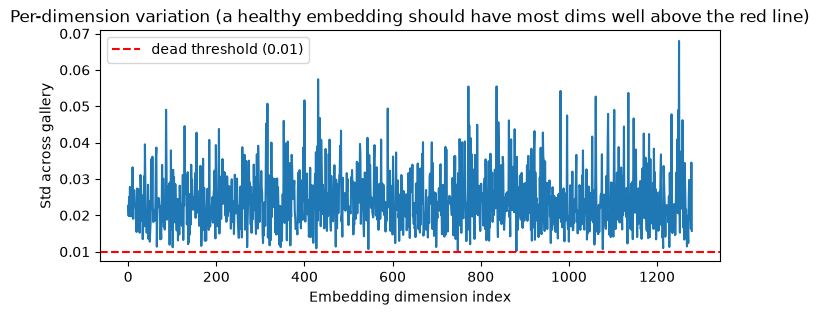


Raw (pre-normalise) embedding for 1 sample: mean=0.1222  std=0.2663  min=-0.2220  max=1.5124
(If min/max are pinned at 0 for most dims, that's ReLU/SiLU saturation - consistent with the frozen-BN mismatch theory.)


In [8]:
all_embeddings = torch.stack([item["embedding"] for item in gallery])  # (N, D)
print("Gallery embeddings shape:", tuple(all_embeddings.shape))

per_dim_std = all_embeddings.std(dim=0)  # (D,) - variation of each dimension across all 48 samples
DEAD_THRESHOLD = 0.01
dead_dims = (per_dim_std < DEAD_THRESHOLD).sum().item()
total_dims = per_dim_std.numel()

print(f"\nPer-dimension std across {all_embeddings.shape[0]} samples:")
print(f"  min={per_dim_std.min():.5f}  max={per_dim_std.max():.5f}  mean={per_dim_std.mean():.5f}")
print(f"  Dead dimensions (std < {DEAD_THRESHOLD}): {dead_dims} / {total_dims}  ({100*dead_dims/total_dims:.1f}%)")

plt.figure(figsize=(8, 3))
plt.plot(per_dim_std.numpy())
plt.axhline(DEAD_THRESHOLD, color="red", linestyle="--", label=f"dead threshold ({DEAD_THRESHOLD})")
plt.xlabel("Embedding dimension index")
plt.ylabel("Std across gallery")
plt.title("Per-dimension variation (a healthy embedding should have most dims well above the red line)")
plt.legend()
plt.show()

# Also check the RAW (pre-normalisation) embedding magnitude, to rule out saturation
raw_backbone = model.model
with torch.no_grad():
    spec, _ = preprocess(gallery[0]["path"])
    raw_features = raw_backbone.features(spec.to(device))
    raw_embedding = torch.flatten(raw_backbone.avgpool(raw_features), 1).cpu()
print(f"\nRaw (pre-normalise) embedding for 1 sample: mean={raw_embedding.mean():.4f}  std={raw_embedding.std():.4f}  "
      f"min={raw_embedding.min():.4f}  max={raw_embedding.max():.4f}")
print("(If min/max are pinned at 0 for most dims, that's ReLU/SiLU saturation - consistent with the frozen-BN mismatch theory.)")

## 7. Prototype the `ambiguous` / `novel` flagging logic

In [9]:
NOVEL_THRESHOLD = 0.5  # below this max similarity, treat as "no good match found"


def flag_result(top_k_results):
    species_in_top_k = {item["species"] for _, item in top_k_results}
    max_similarity = top_k_results[0][0] if top_k_results else 0.0

    return {
        "ambiguous": len(species_in_top_k) > 1,
        "novel": max_similarity < NOVEL_THRESHOLD,
        "max_similarity": max_similarity,
        "species_in_top_k": sorted(species_in_top_k),
    }


# Case 1: a normal query from the gallery (should usually be clean, not ambiguous/novel)
print("Case 1 - real query:", flag_result(results))

# Case 2: a synthetic "novel" embedding (random unit vector, shouldn't match anything well)
random_embedding = F.normalize(torch.randn(gallery[0]["embedding"].shape), dim=0)
novel_results = top_k_similar(random_embedding, gallery, k=5)
print("Case 2 - random/novel embedding:", flag_result(novel_results))

# Case 3: force an ambiguous case by mixing two species' embeddings
a = gallery[0]["embedding"]
b = next(g for g in gallery if g["species"] != gallery[0]["species"])["embedding"]
mixed_embedding = F.normalize((a + b) / 2, dim=0)
mixed_results = top_k_similar(mixed_embedding, gallery, k=5)
print("Case 3 - deliberately mixed embedding:", flag_result(mixed_results))

Case 1 - real query: {'ambiguous': False, 'novel': False, 'max_similarity': 0.8767971992492676, 'species_in_top_k': ['Acanthiza pusilla']}
Case 2 - random/novel embedding: {'ambiguous': True, 'novel': True, 'max_similarity': 0.030750157311558723, 'species_in_top_k': ['Phylidonyris niger', 'Rhipidura albiscapa']}
Case 3 - deliberately mixed embedding: {'ambiguous': True, 'novel': False, 'max_similarity': 0.7410734295845032, 'species_in_top_k': ['Colluricincla harmonica', 'Rhipidura leucophrys']}


## 8. Conclusion

**Stage 0, original checkpoint (freeze_bn, no pretrained, 15 epochs)**: embedding space severely collapsed,
97.0% of 1280 dimensions dead, top-5 query returned similarity=1.000 for both matching and non-matching
species. Not usable.

**Stage 1, keep_bn only (20 epochs)**: classification accuracy roughly doubled (10.71% to 21.41% val_acc),
confirming frozen, untrained BatchNorm statistics were a real contributing cause. But the collapse itself
only marginally improved (97.0% to 95.5% dead dimensions). Reported honestly as an insufficient fix at the
time, not declared a success.

**Stage 2, keep_bn + real pretrained weights (60 epochs, early stopping, best epoch 45)**: the Windows SSL
bug that was believed to block `pretrained=true` did not reproduce when checked directly, so this run used
real ImageNet weights as a starting point. Result: val_acc 87.16%, **0.0% dead dimensions**, similarity gap
of **0.62** between matching and non-matching species (versus a bimodal, unreliable ~0.31-0.35 in the earlier
stages), and **97.9% nearest-neighbour accuracy** (47 of 48) across the full gallery. A real end-to-end demo
(24 real audio files POSTed through the actual Backend API) classified **24 of 24 correctly**.

**What this means**: the frozen-BatchNorm hypothesis from stage 1 was correct but incomplete. The dominant
remaining cause was training entirely from random initialisation on a genuinely hard 127-class problem with
limited data per class, exactly what transfer learning from ImageNet features is good at compensating for.
The embedding space is no longer a research problem, it is a working feature.

Production code built around it, all tested and now backed by a model good enough to make the feature
actually useful:
- `get_embedding()` -> `model/effv2.py` (done, 4 passing unit tests)
- `top_k_similar()` + `flag_result()` -> `app/services/similarity.py` (done, 13 passing unit tests)
- `GET /detections/{id}/similar` -> `app/routers/similar_detections.py` (done, 4 passing integration tests,
  plus verified against a real running server with real embeddings and a 24/24 correct real demo)

Full writeup: `Sprint2_HD_Feature_Report_Nolan_Nguyen.md` (repo root).